### Ivy Mutodi (2023721380) Assignment 4


#### 1. Project Title: Classifying mental health conditions from social media text using NLP
##### Track A: Text-Classification
##### Trying to answer the question : Can a fine-tuned transformer-based language model accurately classify the mental health status of an individual based solely on the language patterns present in their social media posts?
##### Using the dataset : Sentiment analysis for mental heath from kaggle

#### 2.  Data loading and visual data inspection

##### Loading necessary libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [55]:
# Using pandas to load the dataset
df = pd.read_csv('Combined Data.csv')

##### The size of the dataset

In [56]:

print('The dataset contains {} rows and {} columns.'.format(df.shape[0], df.shape[1]))

The dataset contains 53043 rows and 3 columns.


#### Dataset columns

In [57]:
df.columns.tolist()

['Unnamed: 0', 'statement', 'status']

##### Renaming the columns of the dataset

In [58]:
df.rename(columns={'Unnamed: 0' : 'ID' , 'statement': 'Statement' , 'status' : 'Status'} , inplace=True)

##### Few examples of rows

In [59]:
df.head()

,ID,Statement,Status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless heart. All out...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay in a restl...",Anxiety
3,3,I've shifted my focus to something else but I'm still wo...,Anxiety
4,4,"I'm restless and restless, it's been a month now, boy. W...",Anxiety


##### Identifying the count per category

In [60]:
sts = df.groupby(['Status']).size().reset_index(name='Count')
sts

,Status,Count
0,Anxiety,3888
1,Bipolar,2877
2,Depression,15404
3,Normal,16351
4,Personality disorder,1201
5,Stress,2669
6,Suicidal,10653


* Column investigations

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         53043 non-null  int64
 1   Statement  52681 non-null  str  
 2   Status     53043 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.2 MB


In [62]:
df.dtypes

ID           int64
Statement      str
Status         str
dtype: object

In [63]:
df.describe(include='all')

,ID,Statement,Status
count,53043.000000,52681,53043
unique,NaN,51073,7
top,NaN,what do you mean?,Normal
freq,NaN,22,16351
mean,26521.000000,NaN,NaN
std,15312.339501,NaN,NaN
min,0.000000,NaN,NaN
25%,13260.500000,NaN,NaN
50%,26521.000000,NaN,NaN
75%,39781.500000,NaN,NaN


#### 3. Data quality checks and exploration

<Axes: >

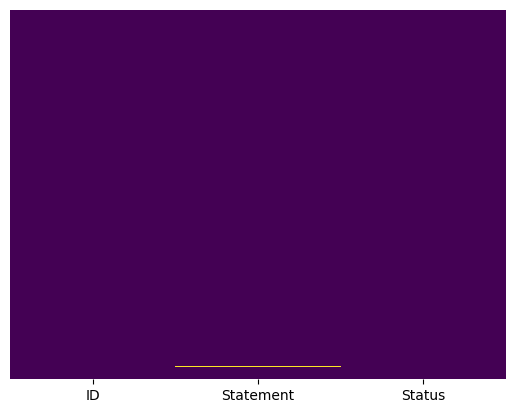

In [64]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

##### From the heatmap, it is clear that we only have missing statements in the dataset.

In [65]:
# To calculate the percentage of missing statement data
print(f"Missing statement {df['Statement'].isna().sum()}")
print(f"Percentage of missing statement data: {df['Statement'].isnull().sum() * 100/53043:.2f}%")    

Missing statement 362
Percentage of missing statement data: 0.68%


In [66]:
missing_by_class = df[df['Statement'].isnull()]['Status'].value_counts()
missing_by_class

Status
Personality disorder    124
Bipolar                 100
Stress                   82
Anxiety                  47
Normal                    8
Suicidal                  1
Name: count, dtype: int64

In [67]:
# total per class
total_per_class = df['Status'].value_counts()

# missing per class
missing_per_class = df[df['Statement'].isnull()]['Status'].value_counts()

# combine into one table
comparison = pd.DataFrame({
    'Total': total_per_class,
    'Missing': missing_per_class
})

comparison['Missing_Percentage'] = (comparison['Missing'] / comparison['Total']) * 100

comparison

,Total,Missing,Missing_Percentage
Status,,,
Anxiety,3888,47.0,1.208848
Bipolar,2877,100.0,3.475843
Depression,15404,NaN,NaN
Normal,16351,8.0,0.048927
Personality disorder,1201,124.0,10.324729
Stress,2669,82.0,3.072312
Suicidal,10653,1.0,0.009387


##### Further anaylsis showed that the Personal disorder had the most missing values while suicidal the least had only 1 missing value.The missing values are not evenly distrubuted across classes,most classes have < 5% missing values thus removing missing values will slightly reduce some classes more than others.The overal impact is still small except for Personality disorder(10%)

In [69]:
df.dropna(inplace=True)
df.isnull().sum()

ID           0
Statement    0
Status       0
dtype: int64

In [70]:
# The dataset size is now reduced after dropping the missing values
df.shape 

(52681, 3)

##### Since the text data is required for NLP models, rows with missing statements were removed.Although this may slightly affect class distribution, particularly for the Personal disorder class, the overall proportion of missing data was small enough to drop the missing values.

In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
duplicates = df[df.duplicated()]
duplicates.head()

,ID,Statement,Status


##### The dataset does not contain any duplicate rows

In [73]:
df_status = df.groupby(['Status']).size().reset_index(name='Count')
df_status

,Status,Count
0,Anxiety,3841
1,Bipolar,2777
2,Depression,15404
3,Normal,16343
4,Personality disorder,1077
5,Stress,2587
6,Suicidal,10652


##### Using seaborn to visualize the category after droping missing values

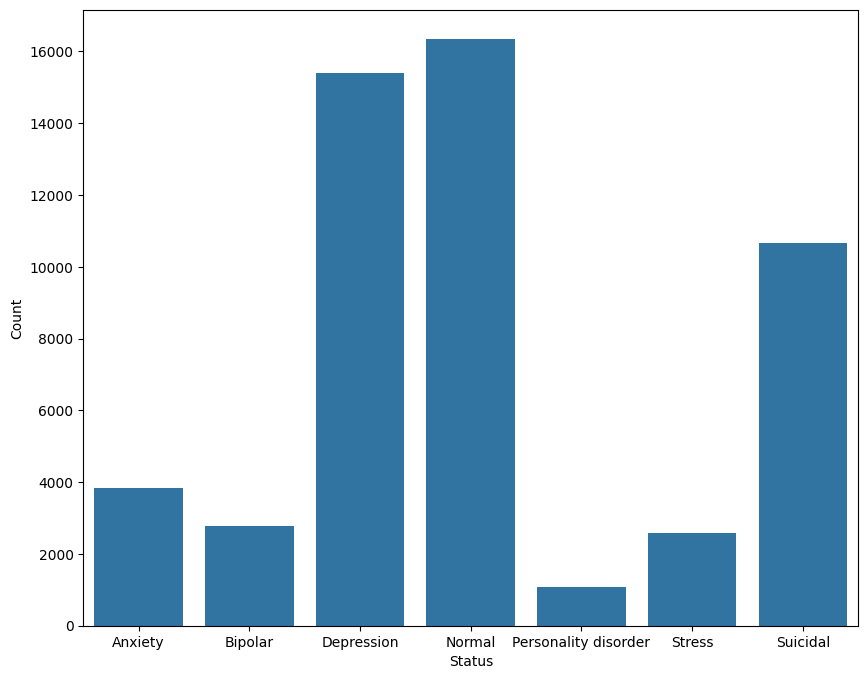

In [74]:
plt.figure(figsize=(10,8))
sns.barplot(data=df_status,x='Status' , y='Count') 
plt.show()

##### The dataset is too big, Im trying to reduce it to 7000 rows but l want to do it according to the proportions of each category inorder to minimize information loss and ensure all subgroups are represented proportionally, 

######  There is 7,29% of anxiety data, but i want to be left with (7000 *7,29%)/ 100 of anxiety data

In [75]:

anxiety_df = df[df['Status'] == 'Anxiety']  
target_n = int(round(7000 * 7.29 / 100)) 

anxiety_sample = anxiety_df.sample(n=target_n, random_state=42)
anxiety_sample.shape

(510, 3)

###### There is 5,27 % of bipolar data, but i want to be left with (7000 *5,27%)/ 100 of bipolar data

In [76]:

bipolar_df = df[df['Status'] == 'Bipolar'] 
target_b = int(round(7000 * 5.27 /100))

bipolar_sample =bipolar_df.sample(n=target_b , random_state=42)
bipolar_sample.shape  

(369, 3)

###### There is 29,24% of depression data, but i want to be left with (7000 *29,24%)/ 100 of depression data

In [77]:

depression_df = df[df['Status'] == 'Depression']
target_d = int(round(7000 * 29.24 /100))
depression_sample = depression_df.sample(n=target_d , random_state=42)
depression_sample.shape

(2047, 3)

######  There is 31.02% of normal data, but i want to be left with (7000 *31.02%)/ 100 of normal data

In [78]:

normal_df = df[df['Status'] == 'Normal']
target_nor = int(round(7000 * 31.02/100))  
normal_sample = normal_df.sample(n=target_nor , random_state=42)
normal_sample.shape

(2171, 3)

###### there is 2,04% of personality disorder data, but i want to be left with (7000 *2,04%)/ 100 of personality disorder data

In [79]:

personality_df = df[df['Status'] == 'Personality disorder']
target_per = int(round(7000 * 2.04 / 100))
personality_sample = personality_df.sample(n=target_per , random_state=42)
personality_sample.shape    

(143, 3)

###### There is 4,93% of stress data, but i want to be left with (7000 *4,93%)/ 100 of stress data

In [80]:

stress_df = df[df['Status'] == 'Stress']
target_str = int(round(7000 * 4.93 / 100))
stress_sample = stress_df.sample(n=target_str , random_state=42)  
stress_sample.shape

(345, 3)

###### There is 20,22% of suicidal data, but i want to be left with (7000 *20,22%)/ 100 of suicidal data

In [81]:
#There is 20,22% of suicidal data, but i want to be left with (7000 *20,22%)/ 100 of suicidal data
suicidal_df = df[df['Status'] == 'Suicidal']
target_sui = int(round(7000 * 20.22/ 100))
suicidal_sample = suicidal_df.sample(n=target_sui , random_state=42)
suicidal_sample.shape

(1415, 3)

###### Creating a new dataframe by concatenating all the samples together

In [82]:

new_df= pd.concat([anxiety_sample, bipolar_sample, depression_sample, normal_sample, personality_sample, stress_sample, suicidal_sample], ignore_index=True)
new_df.shape

(7000, 3)

In [83]:
new_df.head()

,ID,Statement,Status
0,33925,Is this health anxiety? 1) checking temperature 10 times...,Anxiety
1,53040,Is there any way to sleep better? I can't sleep most of ...,Anxiety
2,52394,Lamictal ? Anyone with good reviews about lamictal?,Anxiety
3,51937,"Has anyone tried EMDR therapy? I just started. If so, wh...",Anxiety
4,35083,would my may2018 ECG of picked this up? worried! so; yes...,Anxiety


In [84]:
new_df.tail()

,ID,Statement,Status
6995,7217,Throwaway because reasons.The absolute shame I am being ...,Suicidal
6996,36574,"@gcoakley13,,2nd is 'i dont want to be here anymore' by ...",Suicidal
6997,24007,i have trouble expressing how i feel so this might be a ...,Suicidal
6998,37166,i ve got exactly 23 days of life left and ive never felt...,Suicidal
6999,20924,I am going to kill myself when I turn 1815 just lookin a...,Suicidal


* Category count of the new dataset

In [85]:
plt_data = new_df.groupby(['Status']).size().reset_index(name='Count')
plt_data

,Status,Count
0,Anxiety,510
1,Bipolar,369
2,Depression,2047
3,Normal,2171
4,Personality disorder,143
5,Stress,345
6,Suicidal,1415


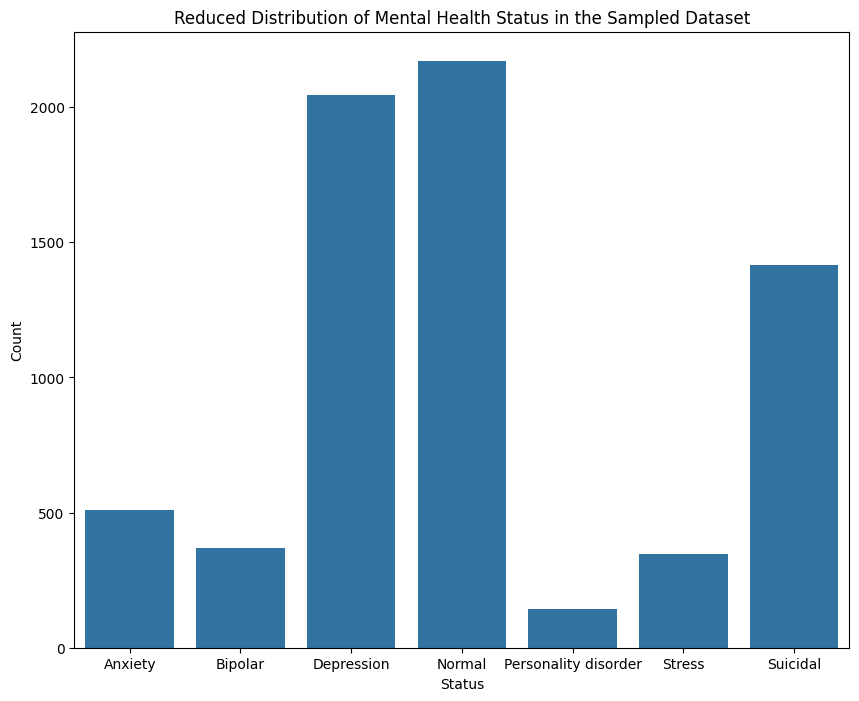

In [86]:
plt.figure(figsize=(10,8))
sns.barplot(data=plt_data,x='Status' , y='Count')
plt.title('Reduced Distribution of Mental Health Status in the Sampled Dataset') 
plt.show()

* Checking for nosisy text/strange characters/encoding issues

In [87]:
#Check for Noisy Text and Encoding Issues

import re

# Check for rows containing URLs
url_pattern = r'http\S+|www\S+|https\S+'
has_url = new_df['Statement'].apply(lambda x: bool(re.search(url_pattern, str(x))))
print(f"Rows containing URLs: {has_url.sum()} ({has_url.sum()*100/len(new_df):.2f}%)")

# Check for rows with special/non-ASCII characters
has_special = new_df['Statement'].apply(lambda x: bool(re.search(r'[^\x00-\x7F]', str(x))))
print(f"Rows with non-ASCII / special characters: {has_special.sum()} ({has_special.sum()*100/len(new_df):.2f}%)")

# Check for rows with excessive numbers 
has_numbers = new_df['Statement'].apply(lambda x: bool(re.search(r'\d{5,}', str(x))))
print(f"Rows with long number sequences (potential noise): {has_numbers.sum()}")

# Check for very short posts 
very_short = new_df[new_df['Statement'].apply(lambda x: len(str(x).split()) < 3)]
print(f"\nVery short posts (< 3 words): {len(very_short)}")
print("\nExamples of very short posts:")
print(very_short[['Statement', 'Status']].head(10).to_string(index=False))

Rows containing URLs: 100 (1.43%)
Rows with non-ASCII / special characters: 799 (11.41%)
Rows with long number sequences (potential noise): 9

Very short posts (< 3 words): 114

Examples of very short posts:
                                        Statement     Status
                                     Very worried    Anxiety
                                      Too nervous    Anxiety
                                     Very worried    Anxiety
                             theekween depression Depression
                                       d pression Depression
                                           #NAME? Depression
                                           #NAME? Depression
fuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuck Depression
                                    Good morning.     Normal
                                     one hundred!     Normal


* The noisy text analysis reveals that the dataset contains URLs, special/non-ASCII characters, and very short uninformative posts. These will be addressed in the preprocessing pipeline. URLs will be removed using regex, non-ASCII characters will be stripped, and the remaining noise (numbers, punctuation) will be cleaned. Very short posts are noted but retained, as even brief statements can carry diagnostic signal.

#### Text length statistics

In [88]:
#Text Length Statistics
new_df['word_count'] = new_df['Statement'].apply(lambda x: len(str(x).split()))
new_df['char_count'] = new_df['Statement'].apply(lambda x: len(str(x)))

# Summary statistics across the whole dataset
print("Text Length Statistics for Full Dataset")
print(new_df[['word_count', 'char_count']].describe().round(2))

Text Length Statistics for Full Dataset
       word_count  char_count
count     7000.00     7000.00
mean       113.37      578.67
std        162.79      828.45
min          1.00        3.00
25%         16.00       81.00
50%         63.00      323.00
75%        149.00      753.00
max       4239.00    19822.00


In [89]:
new_df.head()

,ID,Statement,Status,word_count,char_count
0,33925,Is this health anxiety? 1) checking temperature 10 times...,Anxiety,30,173
1,53040,Is there any way to sleep better? I can't sleep most of ...,Anxiety,17,85
2,52394,Lamictal ? Anyone with good reviews about lamictal?,Anxiety,8,51
3,51937,"Has anyone tried EMDR therapy? I just started. If so, wh...",Anxiety,31,163
4,35083,would my may2018 ECG of picked this up? worried! so; yes...,Anxiety,273,1392


* From the word count anaylsis we can observe that most social media post are relatively short, which aligns with BERT's 512-token limit indicating that truncation will not be an issue for this dataset.

#### 4. Text Preprocessing

* Importing necessary libraries for text preprocessing

In [90]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

In [91]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to C:\Users\Ivy
[nltk_data]     Mutodi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Ivy
[nltk_data]     Mutodi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Ivy
[nltk_data]     Mutodi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [92]:
# Preprocessing for baseline 1: TF-IDF
new_df['sentiment'] = new_df['Status'].map( {'Anxiety':0, 'Bipolar':1 , 'Depression': 2, 'Normal':3, 'Personality disorder':4 , 'Stress': 5, 'Suicidal': 6} )
 

In [93]:
new_df.head()

,ID,Statement,Status,word_count,char_count,sentiment
0,33925,Is this health anxiety? 1) checking temperature 10 times...,Anxiety,30,173,0
1,53040,Is there any way to sleep better? I can't sleep most of ...,Anxiety,17,85,0
2,52394,Lamictal ? Anyone with good reviews about lamictal?,Anxiety,8,51,0
3,51937,"Has anyone tried EMDR therapy? I just started. If so, wh...",Anxiety,31,163,0
4,35083,would my may2018 ECG of picked this up? worried! so; yes...,Anxiety,273,1392,0


In [94]:
new_df.tail()

,ID,Statement,Status,word_count,char_count,sentiment
6995,7217,Throwaway because reasons.The absolute shame I am being ...,Suicidal,141,815,6
6996,36574,"@gcoakley13,,2nd is 'i dont want to be here anymore' by ...",Suicidal,12,62,6
6997,24007,i have trouble expressing how i feel so this might be a ...,Suicidal,319,1507,6
6998,37166,i ve got exactly 23 days of life left and ive never felt...,Suicidal,41,184,6
6999,20924,I am going to kill myself when I turn 1815 just lookin a...,Suicidal,279,1327,6


* Creating a copy of the new dataset

In [95]:
df2 = new_df.copy()


* Preprocessing Pipeline 1 for the baseline model TF-IDF

In [101]:
# converting text to lowercase
df2['Statement'] = df2['Statement'].str.lower()
# Removing URLs, numbers, and punctuation
df2['Statement'] = df2['Statement'].apply(lambda x:  re.sub(r'http\S+|www\S+|https\S+', '', x))
df2['Statement'] = df2['Statement'].apply(lambda x:  re.sub(r'\d+', '', x))
df2['Statement'] = df2['Statement'].apply(lambda x:  re.sub(r'[^\w\s]', '', x))
# Whitespace cleanup
df2['Statement'] = df2['Statement'].apply(lambda x: x.strip())
# Tokenization
df2['tokens'] = df2['Statement'].apply(word_tokenize)


# Stop word removal
stop_words = set(stopwords.words('english'))

negation_words = {'not', 'no', 'nor', 'never'}

stop_words = stop_words - negation_words

df2['tokens'] = df2['tokens'].apply(lambda x: [word for word in x if word not in stop_words])


# Lemmatization
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    tagged_tokens = pos_tag(tokens)
    
    return [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_tokens
    ]

df2['tokens'] = df2['tokens'].apply(lemmatize_tokens)


df2['cleaned_text'] = df2['tokens'].apply(lambda x: ' '.join(x))

In [102]:
df2.head()

,ID,Statement,Status,word_count,char_count,sentiment,tokens,clean_text_bert,cleaned_text
0,33925,is this health anxiety checking temperature times a da...,Anxiety,30,173,0,"[health, anxiety, checking, temperature, time, day, chec...",is this health anxiety checking temperature times a day ...,health anxiety checking temperature time day check blood...
1,53040,is there any way to sleep better i cant sleep most of th...,Anxiety,17,85,0,"[way, sleep, well, cant, sleep, night, med, didnt, help]",is there any way to sleep better i cant sleep most of th...,way sleep well cant sleep night med didnt help
2,52394,lamictal anyone with good reviews about lamictal,Anxiety,8,51,0,"[lamictal, anyone, good, review, lamictal]",lamictal anyone with good reviews about lamictal,lamictal anyone good review lamictal
3,51937,has anyone tried emdr therapy i just started if so what ...,Anxiety,31,163,0,"[anyone, try, emdr, therapy, start, thought, like, far, ...",has anyone tried emdr therapy i just started if so what ...,anyone try emdr therapy start thought like far mostly tr...
4,35083,would my may ecg of picked this up worried so yesterday ...,Anxiety,273,1392,0,"[would, may, ecg, pick, worried, yesterday, drill, wood,...",would my may ecg of picked this up worried so yesterday ...,would may ecg pick worried yesterday drill wood nowhere ...


*  All text was converted to lowercase to ensure that words like 'Happy' and 'happy' are treated the same, present urls were removed as well as numbers and punctuation, extra whitespace was removed, tokens were created as well as stopwords removed, and some words were converted to their root form.

* Pipeline 2 -For BERT (The intended model), If using the BERT model then, there wont be any lemmatization since we dont want to loss contextual information, minimal preprocesiing is applied.Only lowecarsing, URL removal, punctuation removal, numbers.


In [103]:
import re

def clean_for_bert(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df2['clean_text_bert'] = df2['Statement'].apply(clean_for_bert)

In [104]:
df2.head()

,ID,Statement,Status,word_count,char_count,sentiment,tokens,clean_text_bert,cleaned_text
0,33925,is this health anxiety checking temperature times a da...,Anxiety,30,173,0,"[health, anxiety, checking, temperature, time, day, chec...",is this health anxiety checking temperature times a day ...,health anxiety checking temperature time day check blood...
1,53040,is there any way to sleep better i cant sleep most of th...,Anxiety,17,85,0,"[way, sleep, well, cant, sleep, night, med, didnt, help]",is there any way to sleep better i cant sleep most of th...,way sleep well cant sleep night med didnt help
2,52394,lamictal anyone with good reviews about lamictal,Anxiety,8,51,0,"[lamictal, anyone, good, review, lamictal]",lamictal anyone with good reviews about lamictal,lamictal anyone good review lamictal
3,51937,has anyone tried emdr therapy i just started if so what ...,Anxiety,31,163,0,"[anyone, try, emdr, therapy, start, thought, like, far, ...",has anyone tried emdr therapy i just started if so what ...,anyone try emdr therapy start thought like far mostly tr...
4,35083,would my may ecg of picked this up worried so yesterday ...,Anxiety,273,1392,0,"[would, may, ecg, pick, worried, yesterday, drill, wood,...",would my may ecg of picked this up worried so yesterday ...,would may ecg pick worried yesterday drill wood nowhere ...


#### Comparion of data before and after cleaning

In [105]:
#Before and After Preprocessing Comparison
print("BEFORE vs AFTER PREPROCESSING — Sample Comparison")

# Show 5 examples side by side
final_df = pd.DataFrame({
    'Statement':  new_df['Statement'],
    'Cleaned_tfidf':      df2['cleaned_text'],
    'Cleaned_bert':        df2['clean_text_bert'],
    'Sentiment':               df2['sentiment']
})

# Display with wrapping
pd.set_option('display.max_colwidth', 60)
display(final_df)

BEFORE vs AFTER PREPROCESSING — Sample Comparison


,Statement,Cleaned_tfidf,Cleaned_bert,Sentiment
0,Is this health anxiety? 1) checking temperature 10 times...,health anxiety checking temperature time day check blood...,is this health anxiety checking temperature times a day ...,0
1,Is there any way to sleep better? I can't sleep most of ...,way sleep well cant sleep night med didnt help,is there any way to sleep better i cant sleep most of th...,0
2,Lamictal ? Anyone with good reviews about lamictal?,lamictal anyone good review lamictal,lamictal anyone with good reviews about lamictal,0
3,"Has anyone tried EMDR therapy? I just started. If so, wh...",anyone try emdr therapy start thought like far mostly tr...,has anyone tried emdr therapy i just started if so what ...,0
4,would my may2018 ECG of picked this up? worried! so; yes...,would may ecg pick worried yesterday drill wood nowhere ...,would my may ecg of picked this up worried so yesterday ...,0
...,...,...,...,...
6995,Throwaway because reasons.The absolute shame I am being ...,throwaway reasonsthe absolute shame make feel survive at...,throwaway because reasonsthe absolute shame i am being m...,6
6996,"@gcoakley13,,2nd is 'i dont want to be here anymore' by ...",gcoakleynd dont want anymore em,gcoakleynd is i dont want to be here anymore by em too,6
6997,i have trouble expressing how i feel so this might be a ...,trouble express feel might little confuse tire tired exi...,i have trouble expressing how i feel so this might be a ...,6
6998,i ve got exactly 23 days of life left and ive never felt...,get exactly day life leave ive never felt calm peace id ...,i ve got exactly days of life left and ive never felt so...,6


* The comparison above clearly shows the effect of both preprocessing pipelines. For the TF-IDF pipeline, the text is heavily reduced: stopwords, punctuation, URLs, and numbers are removed, and words are lemmatized to their root forms, for the BERT pipeline, the text is more lightly cleaned (lowercasing and URL removal only), stripping stopwords or lemmatizing for BERT would reduce the contextual richness that makes it powerful.

##### 5.Task specific preparation


In [106]:
# Importing necesssary libraries for the sections
from sklearn.model_selection import train_test_split

In [107]:

# 2. Stratified Train/Test Split (80% train, 20% test)
X = final_df[['Statement', 'Cleaned_tfidf', 'Cleaned_bert']]
y = final_df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")

print("Final Modelling-Ready Training Data Preview ")
# Combine back temporarily just to show the preview
train_preview = X_train.copy()
train_preview['label'] = y_train
display(train_preview.head())

Training set size: 5600 samples
Testing set size: 1400 samples

Final Modelling-Ready Training Data Preview 


,Statement,Cleaned_tfidf,Cleaned_bert,label
5395,I don't want to leave my house because I know that every...,dont want leave house know everyone know shes say everyo...,i dont want to leave my house because i know that everyo...,5
6759,I attemempted my life not even a few months ago. From th...,attemempted life not even month ago send short term psyc...,i attemempted my life not even a few months ago from the...,6
4996,missykesson bet you let mcgee on there hahahaha,missykesson bet let mcgee hahahaha,missykesson bet you let mcgee on there hahahaha,3
95,Not doing well My existential OCD is so severe right now...,not well existential ocd severe right spend hour online ...,not doing well my existential ocd is so severe right now...,0
4037,"State I am homeless as of this morning, without mentioni...",state homeless morning without mention title post screen...,state i am homeless as of this morning without mentionin...,3


* Data will be split into train (80%), test (20%) and using stratified sampling to maintain the exact proportion in all subsets.

### 6. Reflection on preprocessing

###  Most important preprocessing decisions
* Having two preprocessing pipeline for the baseline  model TF-IDF and the intended model BERT as mentioned in the project proposal . For the baseline model, deep preprocessing was done were as for the intended model, heavy preprocessing would destroy the linguistic cues that BERT relies on, so only lowercasing and URL removal were applied.

### Limitations and problems encounted
* Even after proportional sampling, the dataset remains imbalanced: Normal and Depression being  dominate, while Personality Disorder has only 143 samples. This imbalance is a core challenge for this project and was acknowledged in the proposal. It will be addressed during modelling using Weighted Cross-Entropy Loss during BERT fine-tuning and will be reflected in the evaluation strategy (Macro-F1 score).
* Noisy and informal social media language: Social media text contains abbreviations, misspellings, slang, emojis, and code-switching. While URLs and punctuation were removed, informal abbreviations (e.g., 'u' for 'you') were not systematically expanded due to the absence of a comprehensive lookup dictionary at this stage. This may reduce the quality of TF-IDF representations but should have less impact on BERT, which was trained on diverse internet text.
* The Personality disorder class: The minority class had the most missing statements(10%), its was wise to drop this column but in a real-world mental health context, Personality Disorder is clinically important, dropping it reduces the real-world relevance of the model, therefore i ddnt drop it.

### What Remains to Be Done Before Modelling and Evaluation

* Abbreviation expansion: Implement a lookup dictionary to expand common social media abbreviations (e.g., 'u' → 'you', 'r' → 'are') before final TF-IDF preprocessing, as outlined in the proposal.
* TF-IDF feature extraction: Apply  TfidfVectorizer from scikit-learn to the Cleaned_tfidf column to produce feature matrices for the baseline Logistic Regression model.
* BERT tokenisation: Apply the HuggingFace BertTokenizer  (WordPiece) to the Cleaned_bert column to produce input_ids, attention_masks, and token_type_ids for fine-tuning.
* Class weight computation: Compute inverse-frequency class weights using (sklearn.utils.class_weight.compute_class_weight) to pass into the Weighted Cross-Entropy Loss function during BERT training.
* Baseline model training: Train and evaluate the TF-IDF + Logistic Regression baseline using the training split.
* BERT fine-tuning: Fine-tune bert-base-uncased using the HuggingFace Trainer API on the training split, monitoring Macro-F1 on the validation split.
* Final evaluation: Evaluate both models on the held-out test set using Macro-F1, per-class precision/recall/F1, and a confusion matrix.